In [10]:
# Cell 1: Setup and imports
import os

os.environ['KERAS_BACKEND'] = 'torch'  # You can change to 'jax' or 'torch' if preferred

import numpy as np
import keras
import sentencepiece as spm

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")

Keras version: 3.9.0
Keras backend: torch


Ladataan datasetti, käyttäen r eli read mode, jotta saadaan kaikki merkit oikein. Varmistetaan että käytetään utf-8 enkoodia, jotta saadaan kaikki merkit oikein. Säilytetään datasetti muuttujaan text.

In [11]:
# Cell 2: Load and prepare text data
# Load the Kalevala text
with open('../datasets/seitsemänveljestä.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()  #.lower()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")

Text length: 627004 characters
First 100 characters: ENSIMMÄINEN LUKU


Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella
rinteellä, liki


In [12]:
# Cell 3: Train SentencePiece model
# Save text to a temporary file for SentencePiece training
temp_file = 'seitsemanveljesta_temp.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)
    f.flush()
    os.fsync(f.fileno())

# Train SentencePiece model
vocab_size = 40000  # You can adjust this based on your needs
model_prefix = 'seitsemänveljestä_sp'

spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,  # Important for Finnish
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>'],
)

# Load the trained tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

# Test tokenization
test_text = "Huikea liuta. Tulispa sinusta oikein kukkomaakari"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁Huikea', '▁liuta', '.', '▁Tulispa', '▁sinusta', '▁oikein', '▁kukkomaakari']
Vocabulary size: 40000


In [13]:
# Cell 4: Prepare training data
# Tokenize the text
seq_length = 64
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

# Create sequences
sequences = []
for i in range(0, len(pieces) - seq_length):
    # Input: first seq_length tokens, Target: next seq_length tokens (shifted by 1)
    sequences.append(pieces[i:i + seq_length + 1])

# Convert to NumPy arrays
sequences = np.array(sequences)
inputs = sequences[:, :-1]  # All tokens except the last one
targets = sequences[:, 1:]  # All tokens except the first one

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

# Split into training and validation sets
indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 103413
Number of sequences: 103349
Input shape: (103349, 64)
Target shape: (103349, 64)


In [14]:
# Cell 5: Define the model
from keras.models import load_model

model_path = 'seitsemänveljestä_model.keras'

def build_model(seq_length, vocab_size):
    def get_positional_encoding(max_len, d_model):
        positions = np.arange(max_len)[:, np.newaxis]
        angles = np.arange(d_model)[np.newaxis, :] / d_model
        angles = 1 / (10000 ** angles)

        pos_encoding = positions * angles
        pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])
        return pos_encoding

    def create_causal_mask(size):
        mask = 1 - np.triu(np.ones((size, size)), k=1)
        return mask

    embed_dim = 256
    num_heads = 4
    ff_dim = 512
    num_layers = 3

    inputs = keras.Input(shape=(seq_length,))
    embedding_layer = keras.layers.Embedding(vocab_size, embed_dim)(inputs)
    pos_encoding = get_positional_encoding(seq_length, embed_dim)
    x = embedding_layer + pos_encoding

    for _ in range(num_layers):
        causal_mask = create_causal_mask(seq_length)
        attention_output = keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )(x, x, attention_mask=causal_mask)

        x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

        ffn = keras.Sequential([
            keras.layers.Dense(ff_dim, activation="relu"),
            keras.layers.Dense(embed_dim),
            keras.layers.Dropout(0.1)
        ])
        ffn_output = ffn(x)
        x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    outputs = keras.layers.Dense(vocab_size)(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    return model

if os.path.exists(model_path):
    print("Ladataan aiemmin tallennettu malli")
    model = load_model(model_path)
    model_trained = True
else:
    print("Luodaan uusi malli")
    model = build_model(seq_length, sp.get_piece_size())
    model_trained = False

model.summary()

Luodaan uusi malli


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 64, 256)   │ 10,240,000 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 64, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_2 (Cast)       │ (None, 64, 256)   │          0 │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_3 (Cast)       │ (None, 64, 256)   │          0 │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ cast_2[0][0],     │
│ (MultiHeadAttentio… │                   │            │ cast_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 64, 256)   │          0 │ add_7[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 64, 256)   │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 64, 256)   │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ layer_normalizat

 Total params: 22,101,312 (84.31 MB)

 Trainable params: 22,101,312 (84.31 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Cell 6: Train the model
if not model_trained:
    print("Aloitetaan koulutus")
    history = model.fit(
        train_inputs, train_targets,
        validation_data=(val_inputs, val_targets),
        batch_size=64,
        # Koulutetaan vain viisi epookkia, koska tämän jälkeen suorituskyky ei enää parane ja early stopping ei jostain syystä toiminut.
        epochs=5,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
            keras.callbacks.ModelCheckpoint(model_path, save_best_only=True)
        ]
    )

Aloitetaan koulutus
Epoch 1/5
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1133 - loss: 7.4985

2025-04-23 12:54:44.383966: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745402084.551833    1008 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745402084.597620    1008 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745402084.987500    1008 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745402084.987516    1008 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745402084.987517    1008 computation_placer.cc:177] computation placer alr

1292/1292 ━━━━━━━━━━━━━━━━━━━━ 112s 87ms/step - accuracy: 0.1133 - loss: 7.4977 - val_accuracy: 0.2934 - val_loss: 4.5017 - learning_rate: 3.0000e-04
Epoch 2/5
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 104s 81ms/step - accuracy: 0.4158 - loss: 3.5352 - val_accuracy: 0.8423 - val_loss: 0.8642 - learning_rate: 3.0000e-04
Epoch 3/5
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 106s 82ms/step - accuracy: 0.8842 - loss: 0.6582 - val_accuracy: 0.9594 - val_loss: 0.2359 - learning_rate: 3.0000e-04
Epoch 4/5
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 105s 81ms/step - accuracy: 0.9621 - loss: 0.2214 - val_accuracy: 0.9678 - val_loss: 0.1757 - learning_rate: 3.0000e-04
Epoch 5/5
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 104s 81ms/step - accuracy: 0.9701 - loss: 0.1617 - val_accuracy: 0.9702 - val_loss: 0.1583 - learning_rate: 3.0000e-04


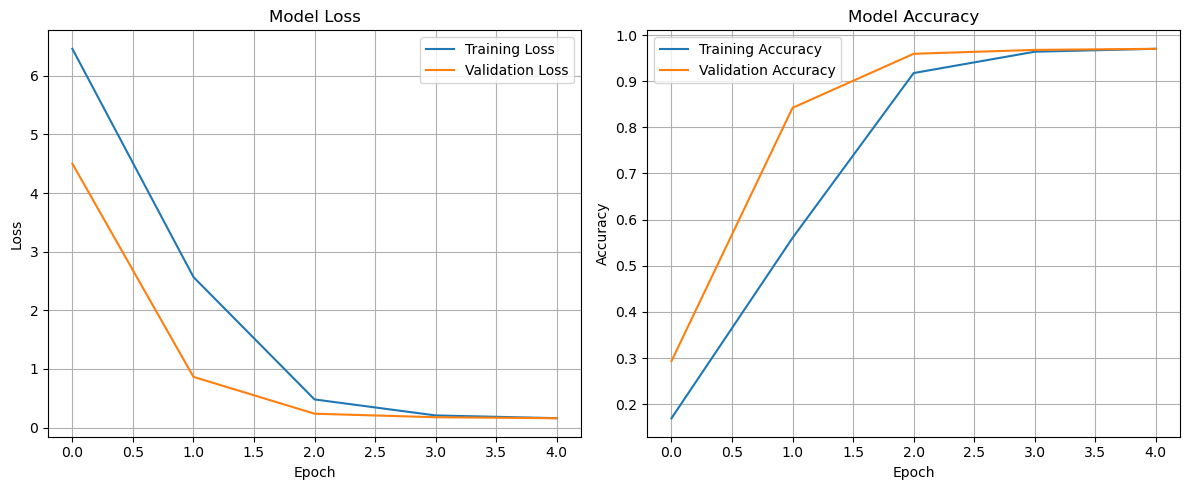

In [16]:
# Cell 7: Plot training metrics
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# Cell 8: Save the model
model.save('seitsemänveljestä_model.keras')
print("Model saved as 'seitsemänveljestä_model.keras'")

Model saved as 'seitsemänveljestä_model.keras'


In [18]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """Generate text based on a prompt with proper lowercase handling."""
    # Convert prompt to lowercase to match training data
    lowercase_prompt = prompt  #.lower()

    # Encode the prompt
    input_ids = sp.encode_as_ids(lowercase_prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text

In [19]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import torch

audio_file = "../datasets/whisper/testi2.wav"

def transcribe_audio_with_whisper(audio_array, sr=16000, model_size="large"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model_name = f"openai/whisper-{model_size}"
    
    processor = WhisperProcessor.from_pretrained(model_name)
    model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)
    
    forced_decoder_ids = processor.get_decoder_prompt_ids(language="fi", task="transcribe")
    
    input_features = processor(
        audio_array, 
        sampling_rate=sr, 
        return_tensors="pt"
    ).input_features.to(device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            input_features,
            forced_decoder_ids=forced_decoder_ids
        )
    
    transcription = processor.batch_decode(
        generated_ids, 
        skip_special_tokens=True
    )[0]
    
    return transcription


Testataan ensin tekstin generointi default parametreilla, eli 100 tokenia ja lämpötila 1.0.

In [20]:
import librosa

# Cell 10: Generate sample text
prompts = [
    "Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää."
]


def generate_text_for_prompts(prompts, num_tokens, temperature):
    for prompt in prompts:
        print(f"\nPrompt: {prompt}")
        generated = generate_text(model, sp, prompt, num_tokens, temperature)
        print(generated)

y, sr = librosa.load(audio_file, sr=16000)
# large model
transcription = transcribe_audio_with_whisper(y, sr)
generate_text_for_prompts(prompts=prompts, num_tokens=100, temperature=1.0)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Prompt: Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää.
Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää. Tule, eihän tuo hirveä piankin tästä täysi Joka ilmast' neljäst'; Maailmat kumoon juttelevat. Sata sarvee seljäss'. Kaisan huulet massahtelee, Napsuttelee kirves, Kreeta-muori Kaisan kynsiss', Juttuu hampaat irviss'. Mutta tuolla tarhan puoless', Mikä pauhu? Heisaa! Kyltät, kaltit saarnailevat, Pikku-porsaat veisaa. Miksi kyltät rähisevät? Miksi naskit kirkuu? Katsos: läätin oven alla Mikon veitsi vilkkuu. Hyvin vaiti, Kaisa hyvin kaikki; mutta Kekkurin torppaan. Oli kaikki kasken kaataminen aljettiin: kirveet paukahtelivat, metsä kaikui, ja rytinällä


In [21]:
transcription = transcribe_audio_with_whisper(y, sr, model_size="medium")
print(transcription)

 Mitä se Vesa vastasi? Vastasi mulle, ei se vastannut siihen että se on paskaa. Mihin se sit vastasi? No oikei se kurssein mitä mä laitain sille että...


Muutetaan ensin lämpötilaa, mikä vaikuttaa tekstin satunnaisuuteen. Mitä pienempi lämpötila sitä loogisempaa teksti on, mutta myös vähemmän luovaa. Mitä suurempi lämpötila, sitä satunnaisempaa ja luovempaa teksti on, mutta myös vähemmän järkevää.


In [22]:
generate_text_for_prompts(prompts=prompts, num_tokens=100, temperature=0.7)


Prompt: Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää.
Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää. Sen läheisin ympäristö on kivinen tanner, mutta alempana alkaa pellot, joissa, ennenkuin talo oli häviöön mennyt, aaltoili teräinen vilja. Peltojen alla on niittu, apilaäyräinen, halkileikkaama monipolvisen ojan; ja runsaasti antoi se heiniä, ennenkuin joutui laitumeksi kylän karjalle. Muutoin on talolla avaria metsiä, soita ja erämaita, jotka, tämän tilustan ensimmäisen perustajan oivallisen toiminnan kautta, olivat langenneet sille osaksi jo ison-jaon käydessä entisinä aikoina. Silloinpa Jukolan isäntä, pitäen enemmän huolta jälkeentulevainsa edusta kuin omasta parhaastansa, otti vastaan osaksensa kulon polttaman metsän ja


Kuten alhaalta näemme, lämpötilan laskeminen 0.2:een tekee tekstistä paljon järkevämpää ja vähemmän satunnaista. Tekstissä on kuitenkin paljon suoria kopioita alkuperäisestä tekstistä.

In [23]:
generate_text_for_prompts(prompts=prompts, num_tokens=100, temperature=0.2)


Prompt: Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää.
Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää. Sen läheisin ympäristö on kivinen tie ja vieläpä lähteen reunalta kohosi ylös kaunis, viherjöitsevä puu, kantain herttaisimpia hedelmiä, jotka eivät ottaen loppuneet; ja siitä sai mies suloisen ravintonsa. Tässä vietti hän päivänsä, ylistäen Herraa, tässä hän vietti yönsä, uneksuen autuitten maasta. Ja hänen päivänsä oli kuin kesän päivä, lämmin ja kirkas, ja hänen yönsä herttaista hämärän aikaa. Niin kului vuosi, ja virtana juoksi Hämeessä kristittyin veri. Mutta koska vainon kauhistava aastaika oli kiertynyt umpeen ja ulkona paistoi ihana syyskuun-aamu, ehti sankarin korviin vasarain


Seuraavaksi testataan korkealla lämpötilalla.

In [24]:
generate_text_for_prompts(prompts=prompts, num_tokens=100, temperature=2.0)


Prompt: Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää.
Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää. Sitä selkeästi onnen entisten tuuheitten elelee perun, pienoseni; mutta tulipas hän uskaltaisi keskustelma. tosi veljeksiin ja muutama meille syytä, sillä suovat reuhtoilivat, valaansa, ja viaton kuin kohottaneet ylös,ksen Kääppä pampahtelis. muorilta ärhenteli, Kreeta-muori Kauhistunpa ammoittavasta setänsä vetonuoraa ja länteen juoksi teet, niin toivokaamme, mieltä laihopeltoa. Ilmausipa kaikkein tempauksellajatkaat paisumista, ja väikkyen katsokoon kuinka suuhunsa toistakin asiaa hän, vaan kaataa. Hän kiusattava asia ehtinytoimen Valkon ainoana rykmentin nimellä sarvillensa siippansa täällä. pyyt saarnastuolit? kummiaskassa alle mitkä, kuinkahan


Kokeillaan 200 tokenia, jotta saadaan enemmän tekstiä. Lämpötila on 1.0, joten teksti on melko satunnaista.

In [25]:
generate_text_for_prompts(prompts=prompts, num_tokens=150, temperature=1.0)


Prompt: Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää.
Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää. Lautamies Mäkelä, täällä on täällä aina vaan toinen toistansa kuin enkelit; onhan sinullekin maistanut, ilman yhtään veroa ja ulostekoa viljelköön tilaansa ja nauttikoon sen tuotteita niin hän kuin hänen lapsensa, eleskellen rauhassa omalla pohjallansa.--Niin olen minä asiaa aprikoinut. Mitä sanotte. JUHANI. »A, eroita; kyllä jätämme pussit-hah! mielisinpä, mielisinpä jo tuossa paikassa iskeä kiinni kuin kissa raakaan, veriseen paistiin. TUOMAS. Hieman vielä kärsimystä, ja paistimme maistuu yhä uhkeammin. JUHANI. Niin vallan.--Mutta kiittäkäämme, että kuulumme sukuun, joka on oppinut äijän ilman kieltoa. Saunaton talo ei käy laatuun sekä kylpemisen että emännän ja muonamiesten muijien lasten-saamisen tähden. Niin, ryöhäävä sauna, haukkuva halli, kiekuva kukko ja naukuva kissa, nehän o

Kokeillaan 200 tokenia, jotta saadaan enemmän tekstiä. Lämpötila on 0.7, joten teksti on melko satunnaista, mutta järkevämpää.

In [26]:
generate_text_for_prompts(prompts=prompts, num_tokens=200, temperature=0.7)


Prompt: Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää.
Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää. Sen läheisin ympäristö on kivinen tie ja vieläpä lähteen reunalta kohosi ylös parvelle. Siellä hän möyrieli ja kaiveli, kaiveli itsensä lopulta ylöspäin pitkin hongan lahounutta sydäntä, ehti latvan viimeiseen huippuun ja huomasi nyt istuvansa keskellä tuulenpesää hienossa, sammaleisessa karsinassa. »Tässä on minun hyvä olla, tässä tahdon asua ijankaikkisesti», aatteli hän, katsoa tirkistäen pienillä myyräsilmillään kammionsa pienestä akkunasta ulos. Ja hän näki allansa synkeän maailman käärittynä syksyillan ikävään hämärään. Hän näki Impivaaran jyrkän vuoren, mutta mittaamattomassa, mieltä polttavassa kaukaisuudessa, näki siellä iltaisten metsien keskellä tuon alakuloisen pirtin, ja vielä näki hän armaitten veljeinsä heittelevän kiekkoa provastin kanssa sumuisella, kaikuvalla aholla.

Kokeillaan 160 tokenia. Lämpötila on 0.7, syystä, että kirjan teksti on runollista ja sille täytyy antaa jotain tilaa luovuudelle. Teksti on kuitenkin edelleen järkevää ja loogista. 

In [27]:
generate_text_for_prompts(prompts=prompts, num_tokens=160, temperature=0.7)


Prompt: Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää.
Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää. Lautamies Mäkelä, täällä on täällä aina vaan kaikin voimin ja kaikki on meillä jalo seljänvastus. Niin, tuolla on entinen, armas Jukola, tuolla Toukolan kylä, tuolla kirkontorni ja tuolla taasen uhkea Impivaara. Selvästi astuu nyt eteeni elon-retkemme kohtaukset tuon menneen vuoskymmenen helmasta.--Katso kuinka tiemme on juosnut. Me ensin, mutta perin mahdottomina, koetimme pyrkiä kristillisten ihmisten yhteyteen, tehden onnettoman retken kohden juhlallista tornia tuolla ilman partaalla. Oli se kiusan kirottu retki, mutta siinä myös se voimakas ponnistaja, joka meidät väkisinkin pakoitti metsien syvyyteen. Tuonne tuon harmaan, jyrkän vuoren kupeille me siirryimme pois ja rakensimme itsellemme lujan pirtin. Mutta ahne tuli poltti pirttimme tuhaksi, ja silloinpa pojat sudenpenikoina kaa

Nyt sen sijaan, että annamme promptiksi prompts listan, annamme sille valmiiksi luodun whisper transkription. Joka kutsuu funktion transcribe_audio_with_whisper, joka käyttää whisper mallia kääntääkseen äänitteen tekstiksi. 

In [28]:
generate_text_for_prompts(prompts=[transcription], num_tokens=160, temperature=0.7)


Prompt:  Mitä se Vesa vastasi? Vastasi mulle, ei se vastannut siihen että se on paskaa. Mihin se sit vastasi? No oikei se kurssein mitä mä laitain sille että...
Mitä se Vesa vastasi? Vastasi mulle, ei se vastannut siihen että se on paskaa. Mihin se sit vastasi? No oikei se kurssein mitä mä laitain sille että... JUHANI. Etkö siinä riivattu voi hillitä leukojasi ja toista seikkaa takaisin joka luullakseni on jotenkin napakassa. Sillä se on täällä meidän tärkein askelemme, se joko saattaa pään harmaaksi ennen aikoja tai tuo meille elämän poudan ja päättää viimein päivämme illan kultaruskoon. Ja sinuunpa, Juhani, se ensiksi nyt koskee. Huomaa siis mitä sanon: Emännätön isännyys on puoletonta ja ontuvaa; talo ilman aitan polulla astelevaa emäntää... TIMO. On niinkuin suden pesä ilman naarassutta, tai niinkuin saapas ilman toista saapasta; totisesti ontuupa se, niinkuin Aapo sanoi. AAPO. Talo ilman aitan polulla astelevata emäntää on niinkuin pilvinen päivä, ja sen perheenpöydän päässä asuu